In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf
import iisignature as isig
from tqdm import tqdm

# --- Configuration ---
SP500_TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "BRK-B", "JPM", "V",
    "JNJ", "UNH", "PG", "XOM", "HD", "MA", "LLY", "CVX", "MRK", "BAC",
    "KO", "PFE", "PEP", "ABBV", "COST", "ORCL", "CMCSA", "WMT", "ADBE", "CRM",
    "ACN", "TMO", "NKE", "DIS", "CSCO", "DHR", "INTC", "NFLX", "VZ", "PYPL",
    "QCOM", "AMD", "TXN", "HON", "AMGN", "SBUX", "IBM", "GE", "MDLZ", "LOW"
]
END_DATE = pd.to_datetime('2025-06-30')
START_DATE = END_DATE - pd.DateOffset(years=5)
TRAINING_WINDOW_YEARS = 2
TESTING_WINDOW_MONTHS = 1
SIGNATURE_DEPTH = 4
NUM_BOOTSTRAP_SAMPLES = 1000

# --- 1. Data Download ---
def download_data(tickers, start, end):
    print(f"Downloading data from {start.strftime('%Y-%m-%d')} to {end.strftime('%Y-%m-%d')}...")
    data = yf.download(tickers, start=start, end=end, progress=False)['Close']
    data = data.dropna(axis=1, how='all')
    initial_columns = data.columns.tolist()
    data = data.dropna()
    final_columns = data.columns.tolist()
    if len(initial_columns) != len(final_columns):
        print(f"Dropped {len(initial_columns) - len(final_columns)} tickers due to missing data.")
    print(f"Downloaded data for {len(final_columns)} tickers.")
    return data

# --- 2. HRP Helper Functions ---
def calculate_distance_matrix_correlation(returns):
    corr_matrix = returns.corr()
    distance_matrix = np.sqrt(0.5 * (1 - corr_matrix))
    return distance_matrix

def calculate_distance_matrix_signature(prices, depth):
    num_assets = prices.shape[1]
    asset_names = prices.columns
    paths = []
    for col in asset_names:
        log_prices = np.log(prices[col].values).reshape(-1, 1)
        time_index = np.linspace(0, 1, len(log_prices)).reshape(-1, 1)
        path = np.hstack([time_index, log_prices])
        paths.append(path)

    kernel_matrix = np.zeros((num_assets, num_assets))
    for i in range(num_assets):
        for j in range(i, num_assets):
            sig_i = isig.sig(paths[i], depth)
            sig_j = isig.sig(paths[j], depth)
            kernel_val = np.dot(sig_i, sig_j)
            kernel_matrix[i, j] = kernel_val
            kernel_matrix[j, i] = kernel_val

    distance_matrix = np.zeros((num_assets, num_assets))
    for i in range(num_assets):
        for j in range(i + 1, num_assets):
            dist_sq = kernel_matrix[i, i] + kernel_matrix[j, j] - 2 * kernel_matrix[i, j]
            distance_matrix[i, j] = np.sqrt(max(0, dist_sq)) # Ensure non-negative
            distance_matrix[j, i] = distance_matrix[i, j]

    return pd.DataFrame(distance_matrix, index=asset_names, columns=asset_names)

def get_quasi_diagonal_order(distance_matrix):
    condensed_distance = squareform(distance_matrix.fillna(0).values)
    linkage_matrix = sch.linkage(condensed_distance, method='single')
    order = sch.dendrogram(linkage_matrix, no_plot=True)['leaves']
    asset_names = distance_matrix.index
    return [asset_names[i] for i in order]

def recursive_bisection_weights(covariance_matrix, order):
    weights = pd.Series(1.0, index=covariance_matrix.index)
    clusters = [order]

    while len(clusters) > 0:
        current_cluster = clusters.pop(0)
        if len(current_cluster) == 1:
            continue

        mid_point = len(current_cluster) // 2
        left_cluster = current_cluster[:mid_point]
        right_cluster = current_cluster[mid_point:]

        if not left_cluster or not right_cluster:
            continue

        cov_left = covariance_matrix.loc[left_cluster, left_cluster]
        cov_right = covariance_matrix.loc[right_cluster, right_cluster]

        var_left = np.diag(cov_left.values)
        weights_left = (1 / var_left) / np.sum(1 / var_left)
        cluster_var_left = np.dot(weights_left, np.dot(cov_left, weights_left))

        var_right = np.diag(cov_right.values)
        weights_right = (1 / var_right) / np.sum(1 / var_right)
        cluster_var_right = np.dot(weights_right, np.dot(cov_right, weights_right))

        alpha = 1 - (cluster_var_left / (cluster_var_left + cluster_var_right))

        weights.loc[left_cluster] *= alpha
        weights.loc[right_cluster] *= (1 - alpha)

        clusters.extend([left_cluster, right_cluster])

    return weights

def build_hrp_portfolio(data_train, method='correlation', signature_depth=2):
    returns_train = data_train.pct_change().dropna()
    lw = LedoitWolf()
    cov_matrix = pd.DataFrame(lw.fit(returns_train).covariance_,
                              index=returns_train.columns, columns=returns_train.columns)

    if method == 'correlation':
        distance_matrix = calculate_distance_matrix_correlation(returns_train)
    else:
        distance_matrix = calculate_distance_matrix_signature(data_train, signature_depth)

    order = get_quasi_diagonal_order(distance_matrix)
    ordered_cov = cov_matrix.loc[order, order]
    weights = recursive_bisection_weights(ordered_cov, order)

    final_weights = pd.Series(0.0, index=cov_matrix.index)
    final_weights.update(weights)
    return final_weights / final_weights.sum()

# --- 3. Portfolio Performance Metrics ---
def calculate_portfolio_metrics(returns_test, weights):
    common_assets = list(set(returns_test.columns) & set(weights.index))
    returns_test = returns_test[common_assets]
    weights = weights[common_assets]

    portfolio_returns = (returns_test * weights).sum(axis=1)
    if portfolio_returns.empty: return {k: 0 for k in ['annualized_return', 'annualized_volatility', 'max_drawdown', 'VaR_95', 'CVaR_95']}

    annualized_return = (1 + portfolio_returns).prod()**(252 / len(portfolio_returns)) - 1
    annualized_volatility = portfolio_returns.std() * np.sqrt(252)
    cumulative_returns = (1 + portfolio_returns).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    VaR_95 = -np.percentile(portfolio_returns, 5)
    cvar_threshold = np.percentile(portfolio_returns, 5)
    CVaR_95 = -portfolio_returns[portfolio_returns <= cvar_threshold].mean()

    return {'annualized_return': annualized_return, 'annualized_volatility': annualized_volatility,
            'max_drawdown': max_drawdown, 'VaR_95': VaR_95, 'CVaR_95': CVaR_95}

# --- 4. Backtesting Loop ---
def run_backtest(data, training_years, testing_months, sig_depth):
    all_dates = data.index.sort_values()
    training_delta = pd.DateOffset(years=training_years)
    testing_delta = pd.DateOffset(months=testing_months)
    results_corr, results_sig = [], []
    current_end_train = all_dates[0] + training_delta

    # Calculate number of iterations
    num_iterations = sum(1 for d in pd.date_range(start=current_end_train, end=all_dates[-1] - testing_delta, freq=testing_delta))

    with tqdm(total=num_iterations, desc="Backtesting Progress") as pbar:
        while current_end_train + testing_delta <= all_dates[-1]:
            training_data = data.loc[current_end_train - training_delta : current_end_train]
            testing_data = data.loc[current_end_train + pd.Timedelta(days=1) : current_end_train + testing_delta]

            if len(training_data) < training_years * 200 or len(testing_data) < testing_months * 20:
                current_end_train += testing_delta
                continue

            weights_corr = build_hrp_portfolio(training_data, method='correlation')
            weights_sig = build_hrp_portfolio(training_data, method='signature', signature_depth=sig_depth)

            returns_test = testing_data.pct_change().dropna()
            if not returns_test.empty:
                results_corr.append(calculate_portfolio_metrics(returns_test, weights_corr))
                results_sig.append(calculate_portfolio_metrics(returns_test, weights_sig))

            current_end_train += testing_delta
            pbar.update(1)

    return pd.DataFrame(results_corr), pd.DataFrame(results_sig)

# --- 5. Statistical Analysis ---
def bootstrap_test_difference(series1, series2, num_samples):
    diffs = (series1 - series2).dropna()
    if diffs.empty: return np.nan, np.nan
    obs_diff_mean = np.mean(diffs)
    bootstrap_means = [np.mean(np.random.choice(diffs, size=len(diffs), replace=True)) for _ in range(num_samples)]
    p_value = np.sum(np.array(bootstrap_means) >= 0) / num_samples
    return obs_diff_mean, p_value

def display_results(df_corr, df_sig):
    print("\n--- Summary Performance (Mean Out-of-Sample) ---")
    summary = pd.DataFrame({'HRP-Correlation': df_corr.mean(), 'HRP-Signature': df_sig.mean()})
    summary['Difference (Sig - Corr)'] = summary['HRP-Signature'] - summary['HRP-Correlation']
    print(summary.to_string())

    print("\n--- Statistical Significance (H0: Sig >= Corr, H1: Sig < Corr) ---")
    print(" (Lower p-value indicates HRP-Signature is significantly better/lower risk)")

    metrics = ['annualized_volatility', 'max_drawdown', 'VaR_95', 'CVaR_95']
    results = {m: bootstrap_test_difference(df_sig[m], df_corr[m], NUM_BOOTSTRAP_SAMPLES) for m in metrics}
    test_df = pd.DataFrame(results, index=['Observed Difference', 'P-value (Bootstrap)']).T
    print(test_df.to_string())
    print("\nNote: A p-value < 0.05 suggests rejecting the null hypothesis in favor of the alternative (HRP-Signature is < HRP-Correlation).")

# --- Main Execution ---
if __name__ == "__main__":
    print("Starting HRP Risk Comparison Backtest...")
    stock_data = download_data(SP500_TICKERS, START_DATE, END_DATE)

    if len(stock_data.columns) < 2:
        print("Not enough valid data for a meaningful backtest. Exiting.")
    else:
        results_corr_df, results_sig_df = run_backtest(stock_data, TRAINING_WINDOW_YEARS, TESTING_WINDOW_MONTHS, SIGNATURE_DEPTH)
        if results_corr_df.empty or results_sig_df.empty:
            print("No backtest results generated.")
        else:
            display_results(results_corr_df, results_sig_df)
        print("\nBacktest complete.")

Starting HRP Risk Comparison Backtest...


/tmp/ipython-input-10-1743731639.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, progress=False)['Close']


Downloaded data for 50 tickers.


Backtesting Progress:  89%|████████▊ | 31/35 [00:28<00:03,  1.10it/s]



--- Summary Performance (Mean Out-of-Sample) ---
                       HRP-Correlation  HRP-Signature  Difference (Sig - Corr)
annualized_return             0.189602       0.211695                 0.022093
annualized_volatility         0.123630       0.126007                 0.002377
max_drawdown                 -0.032538      -0.033038                -0.000499
VaR_95                        0.010101       0.010402                 0.000301
CVaR_95                       0.014314       0.014613                 0.000299

--- Statistical Significance (H0: Sig >= Corr, H1: Sig < Corr) ---
 (Lower p-value indicates HRP-Signature is significantly better/lower risk)
                       Observed Difference  P-value (Bootstrap)
annualized_volatility             0.002377                1.000
max_drawdown                     -0.000499                0.077
VaR_95                            0.000301                0.996
CVaR_95                           0.000299                0.999

Note: A p-v

In [ ]:
!pip install iisignature

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for iisignature: filename=iisignature-0.24-cp311-cp311-linux_x86_64.whl size=3246084 sha256=620ff3196dc49dba88ee4229333ff2634c05ccc14f48cfa175092704d8932537
  Stored in directory: /root/.cache/pip/wheels/1c/f4/57/0b4d3787a07f20a3cd1a91835d6247f55ef899345267bcd6df
Successfully built iisignature


Starting HRP Risk Comparison Backtest...


/tmp/ipython-input-16-2837986620.py:34: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, progress=False)['Close']


Downloaded data for 50 tickers.


Backtesting Progress:  89%|████████▊ | 31/35 [00:21<00:02,  1.43it/s]



--- Summary Performance (Mean Out-of-Sample) ---
                       HRP-Correlation  HRP-Signature  Difference (Sig - Corr)
annualized_return             0.234149       0.240370                 0.006220
annualized_volatility         0.126785       0.128350                 0.001565
max_drawdown                 -0.031707      -0.031781                -0.000074
VaR_95                        0.010343       0.010412                 0.000069
CVaR_95                       0.014882       0.014952                 0.000069

--- Statistical Significance (H0: Sig >= Corr, H1: Sig < Corr) ---
 (Lower p-value indicates HRP-Signature is significantly better/lower risk)
                       Observed Difference  P-value (Bootstrap)
annualized_volatility             0.001565                0.984
max_drawdown                     -0.000074                0.460
VaR_95                            0.000069                0.689
CVaR_95                           0.000069                0.720

Generating 

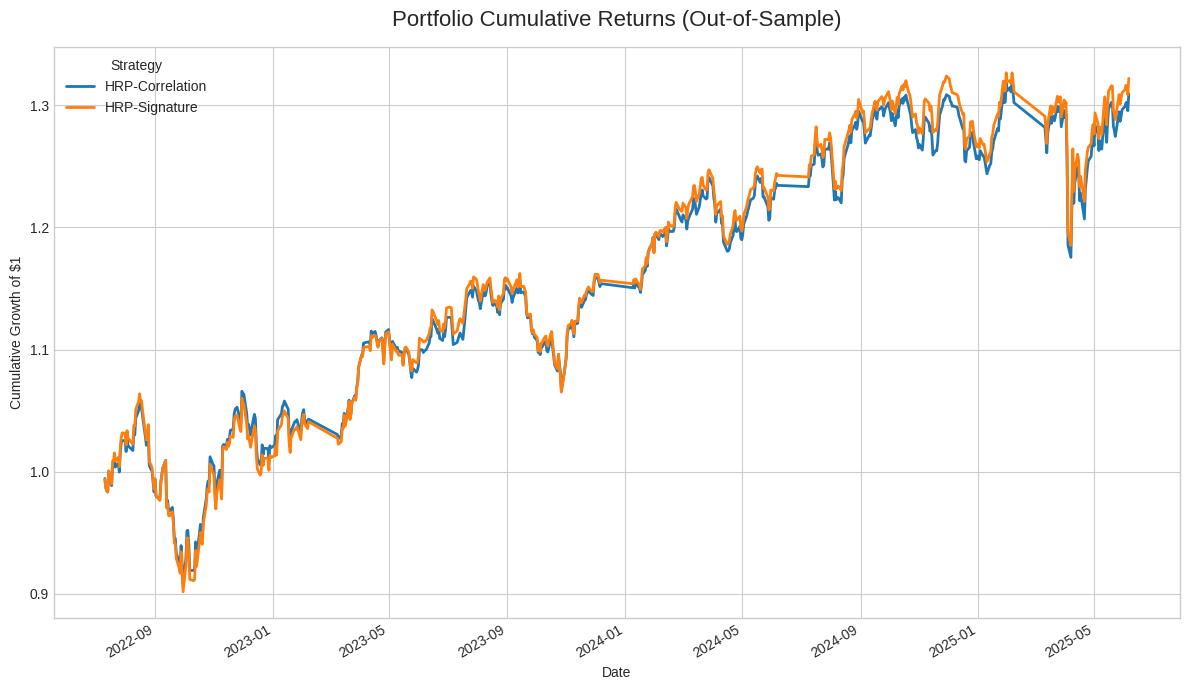

/tmp/ipython-input-16-2837986620.py:313: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  test_end_dates = returns_corr.resample('M').last().index


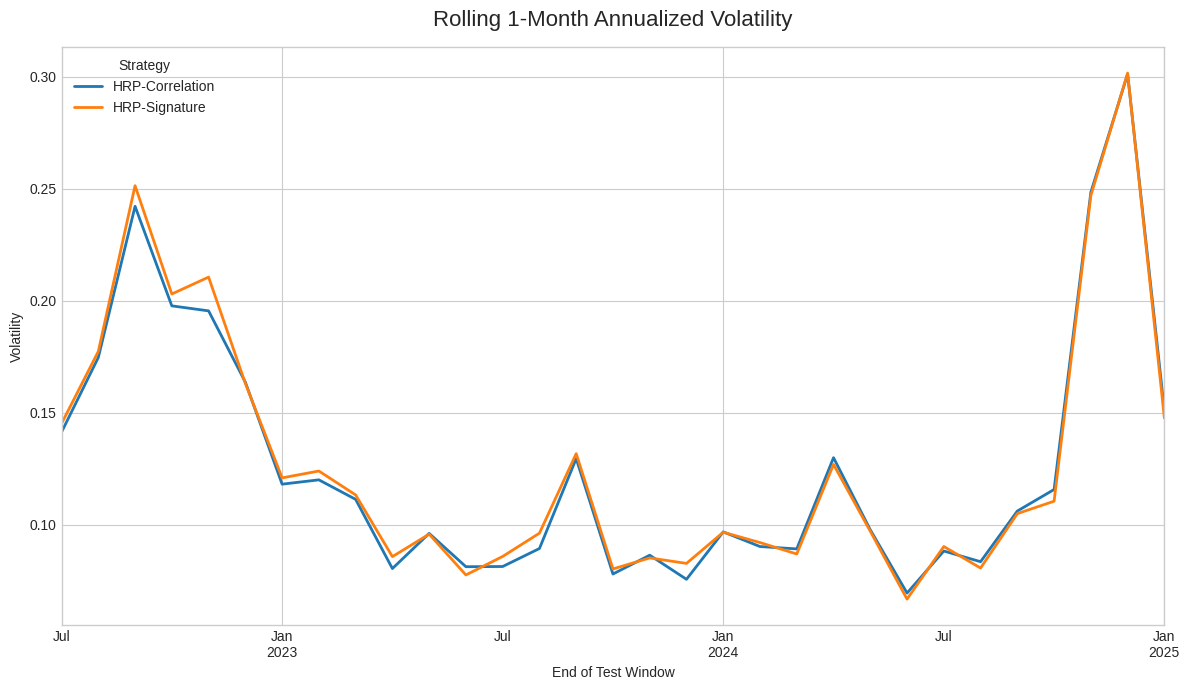

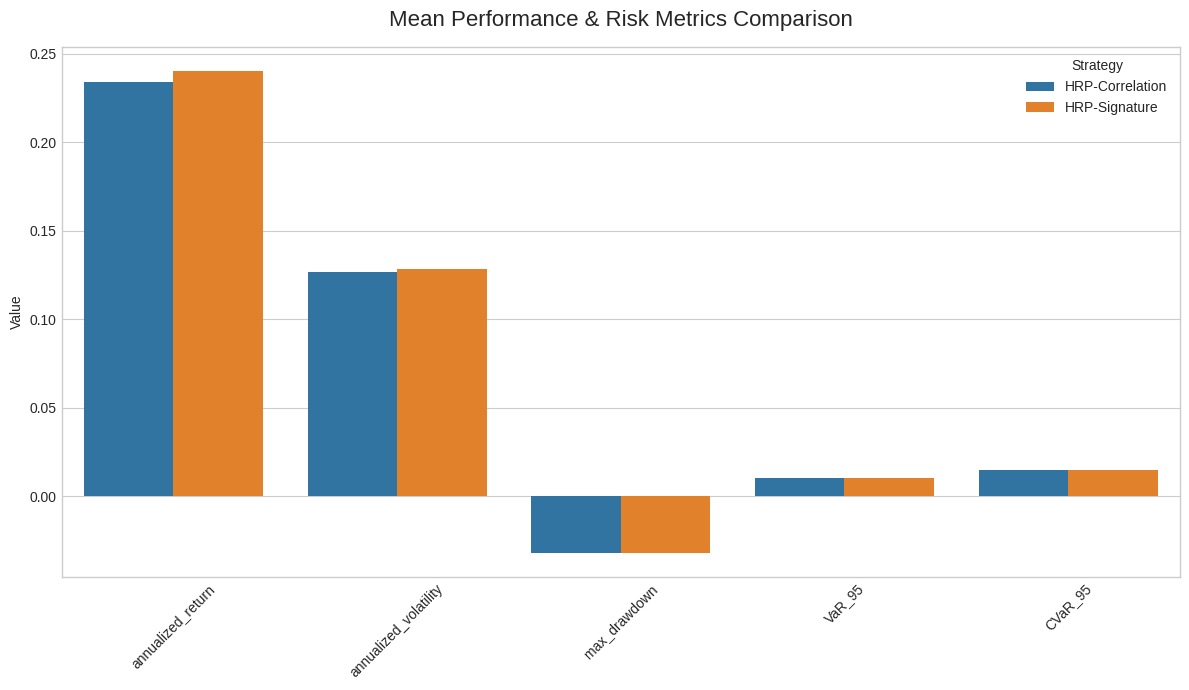


DEMONSTRATING CLUSTERING DETAILS FOR THE LAST PERIOD

--- 4-Cluster Text Output: HRP-Correlation (as of 2025-07-03) ---

Cluster 1A (12 assets): ['UNH', 'LLY', 'NKE', 'SBUX', 'MRK', 'CMCSA', 'VZ', 'HD', 'LOW', 'DIS', 'ACN', 'IBM']
Cluster 1B (13 assets): ['DHR', 'TMO', 'PYPL', 'COST', 'WMT', 'GE', 'TSLA', 'CSCO', 'CVX', 'XOM', 'HON', 'MA', 'V']

Cluster 2A (12 assets): ['BRK-B', 'BAC', 'JPM', 'NFLX', 'ADBE', 'CRM', 'INTC', 'ORCL', 'AAPL', 'QCOM', 'TXN', 'AMD']
Cluster 2B (13 assets): ['NVDA', 'GOOGL', 'MSFT', 'AMZN', 'META', 'PFE', 'JNJ', 'PG', 'KO', 'MDLZ', 'PEP', 'ABBV', 'AMGN']

--- 4-Cluster Text Output: HRP-Signature (as of 2025-07-03) ---

Cluster 1A (12 assets): ['NVDA', 'UNH', 'ORCL', 'GE', 'NFLX', 'LLY', 'NKE', 'PFE', 'INTC', 'PEP', 'TMO', 'ADBE']
Cluster 1B (13 assets): ['MRK', 'COST', 'WMT', 'AMZN', 'BAC', 'META', 'IBM', 'JPM', 'TSLA', 'CMCSA', 'CSCO', 'DIS', 'VZ']

Cluster 2A (12 assets): ['ABBV', 'GOOGL', 'AMGN', 'QCOM', 'BRK-B', 'MA', 'MSFT', 'V', 'PYPL', 'KO', 'HON', 'T

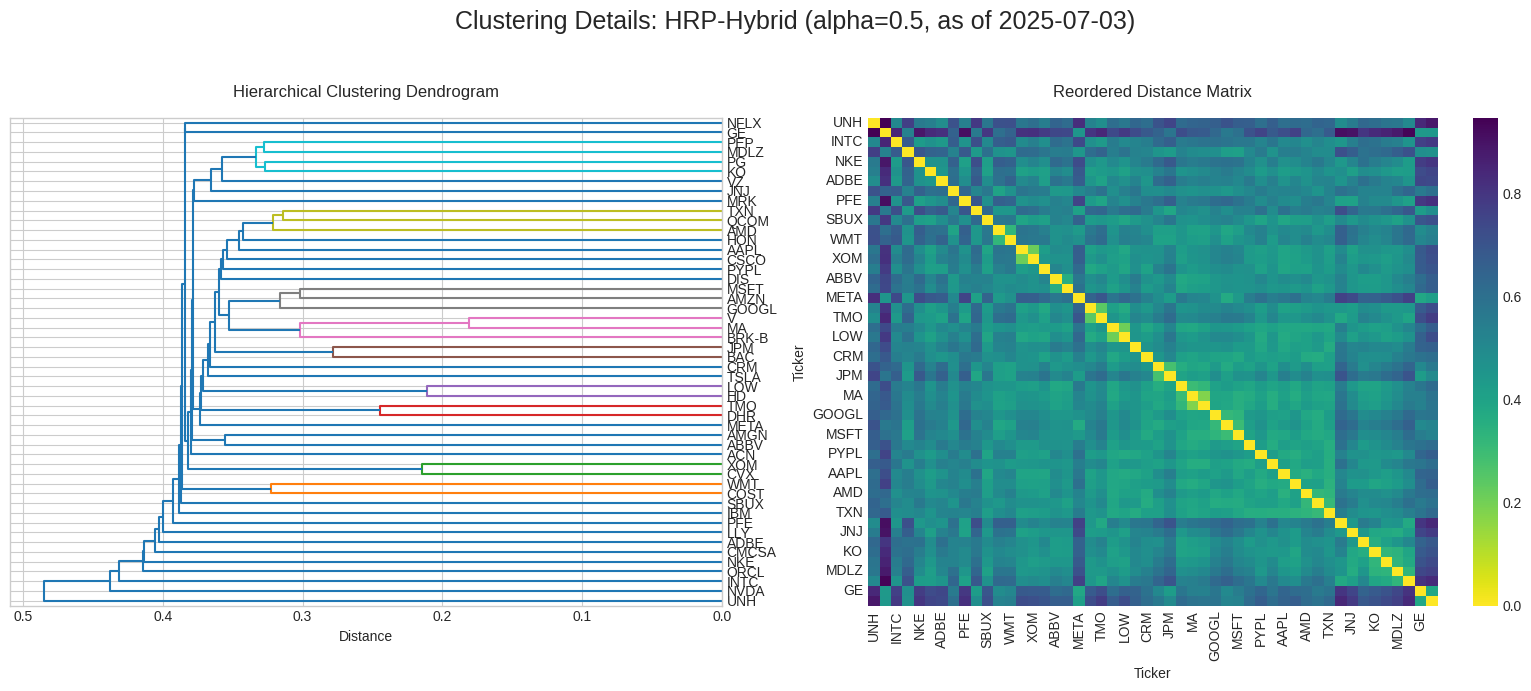

/tmp/ipython-input-16-2837986620.py:272: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_weights.index, y=sorted_weights.values, ax=ax, palette='viridis')


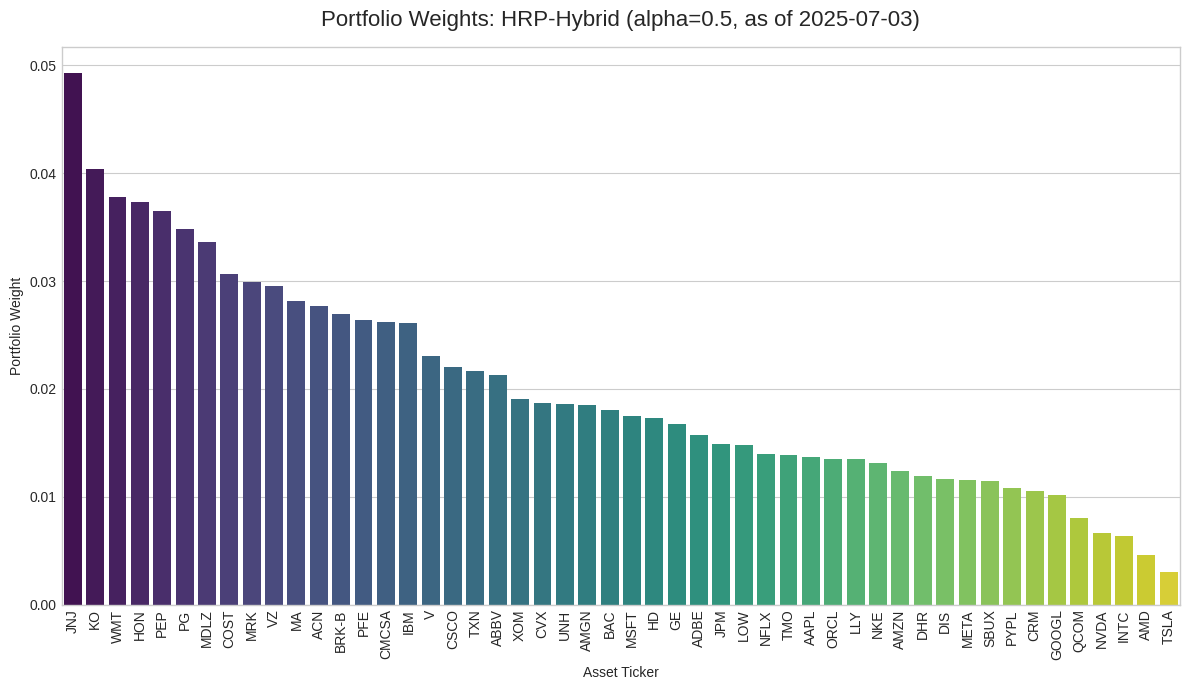


Backtest complete.


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import minmax_scale
import iisignature as isig
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
SP500_TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "BRK-B", "JPM", "V",
    "JNJ", "UNH", "PG", "XOM", "HD", "MA", "LLY", "CVX", "MRK", "BAC",
    "KO", "PFE", "PEP", "ABBV", "COST", "ORCL", "CMCSA", "WMT", "ADBE", "CRM",
    "ACN", "TMO", "NKE", "DIS", "CSCO", "DHR", "INTC", "NFLX", "VZ", "PYPL",
    "QCOM", "AMD", "TXN", "HON", "AMGN", "SBUX", "IBM", "GE", "MDLZ", "LOW"
]
END_DATE = pd.to_datetime('2025-07-07')
START_DATE = END_DATE - pd.DateOffset(years=5)
TRAINING_WINDOW_YEARS = 2
TESTING_WINDOW_MONTHS = 1
SIGNATURE_DEPTH = 2
NUM_BOOTSTRAP_SAMPLES = 1000

# All functions from the previous script remain the same...
# (Code for download_data, calculate_distance_matrix_*, get_quasi_diagonal_order, etc. is omitted for brevity but included in the runnable script below)

# --- [Previous Functions Omitted for Brevity] ---
def download_data(tickers, start, end):
    print(f"Downloading data from {start.strftime('%Y-%m-%d')} to {end.strftime('%Y-%m-%d')}...")
    data = yf.download(tickers, start=start, end=end, progress=False)['Close']
    data = data.dropna(axis=1, how='all')
    initial_columns = data.columns.tolist()
    data = data.dropna()
    final_columns = data.columns.tolist()
    if len(initial_columns) != len(final_columns):
        print(f"Dropped {len(initial_columns) - len(final_columns)} tickers due to missing data.")
    print(f"Downloaded data for {len(final_columns)} tickers.")
    return data

def calculate_distance_matrix_correlation(returns):
    corr_matrix = returns.corr()
    distance_matrix = np.sqrt(0.5 * (1 - corr_matrix))
    return distance_matrix

def calculate_distance_matrix_signature(prices, depth):
    num_assets = prices.shape[1]
    asset_names = prices.columns
    paths = []
    for col in asset_names:
        log_prices = np.log(prices[col].values).reshape(-1, 1)
        time_index = np.linspace(0, 1, len(log_prices)).reshape(-1, 1)
        path = np.hstack([time_index, log_prices])
        paths.append(path)

    kernel_matrix = np.zeros((num_assets, num_assets))
    for i in range(num_assets):
        for j in range(i, num_assets):
            sig_i, sig_j = isig.sig(paths[i], depth), isig.sig(paths[j], depth)
            kernel_matrix[i, j] = np.dot(sig_i, sig_j)
            kernel_matrix[j, i] = kernel_matrix[i, j]

    distance_matrix = np.zeros((num_assets, num_assets))
    for i in range(num_assets):
        for j in range(i + 1, num_assets):
            dist_sq = kernel_matrix[i, i] + kernel_matrix[j, j] - 2 * kernel_matrix[i, j]
            distance_matrix[i, j] = np.sqrt(max(0, dist_sq))
            distance_matrix[j, i] = distance_matrix[i, j]

    return pd.DataFrame(distance_matrix, index=asset_names, columns=asset_names)

def get_quasi_diagonal_order(distance_matrix):
    condensed_distance = squareform(distance_matrix.fillna(0).values)
    linkage_matrix = sch.linkage(condensed_distance, method='single')
    order_indices = sch.dendrogram(linkage_matrix, no_plot=True)['leaves']
    asset_names = distance_matrix.index
    order_names = [asset_names[i] for i in order_indices]
    return order_names, linkage_matrix

def recursive_bisection_weights(covariance_matrix, order):
    weights = pd.Series(1.0, index=covariance_matrix.index)
    clusters = [order]
    while len(clusters) > 0:
        current_cluster = clusters.pop(0)
        if len(current_cluster) == 1: continue

        mid_point = len(current_cluster) // 2
        left_cluster, right_cluster = current_cluster[:mid_point], current_cluster[mid_point:]
        if not left_cluster or not right_cluster: continue

        cov_left, cov_right = covariance_matrix.loc[left_cluster, left_cluster], covariance_matrix.loc[right_cluster, right_cluster]
        var_left, var_right = np.diag(cov_left.values), np.diag(cov_right.values)

        weights_left, weights_right = (1 / var_left) / np.sum(1 / var_left), (1 / var_right) / np.sum(1 / var_right)
        cluster_var_left, cluster_var_right = np.dot(weights_left, np.dot(cov_left, weights_left)), np.dot(weights_right, np.dot(cov_right, weights_right))

        alloc_factor = 1 - cluster_var_left / (cluster_var_left + cluster_var_right) if (cluster_var_left + cluster_var_right) != 0 else 0.5

        weights.loc[left_cluster] *= alloc_factor
        weights.loc[right_cluster] *= (1 - alloc_factor)

        if len(left_cluster) > 1: clusters.append(left_cluster)
        if len(right_cluster) > 1: clusters.append(right_cluster)
    return weights

def build_hrp_portfolio(data_train, method='correlation', signature_depth=2, alpha=0.5):
    returns_train = data_train.pct_change().dropna()
    lw = LedoitWolf()
    cov_matrix = pd.DataFrame(lw.fit(returns_train).covariance_, index=returns_train.columns, columns=returns_train.columns)

    if method == 'correlation':
        distance_matrix = calculate_distance_matrix_correlation(returns_train)
    elif method == 'signature':
        distance_matrix = calculate_distance_matrix_signature(data_train, signature_depth)
    elif method == 'hybrid':
        dist_corr = calculate_distance_matrix_correlation(returns_train)
        dist_sig = calculate_distance_matrix_signature(data_train, signature_depth)
        dist_corr_scaled = pd.DataFrame(minmax_scale(dist_corr.values.flatten()).reshape(dist_corr.shape), index=dist_corr.index, columns=dist_corr.columns)
        dist_sig_scaled = pd.DataFrame(minmax_scale(dist_sig.values.flatten()).reshape(dist_sig.shape), index=dist_sig.index, columns=dist_sig.columns)
        distance_matrix = alpha * dist_sig_scaled + (1 - alpha) * dist_corr_scaled
    else:
        raise ValueError("Method must be 'correlation', 'signature', or 'hybrid'")

    order, linkage = get_quasi_diagonal_order(distance_matrix)
    ordered_cov = cov_matrix.loc[order, order]
    weights = recursive_bisection_weights(ordered_cov, order)

    final_weights = pd.Series(0.0, index=cov_matrix.index)
    final_weights.update(weights)
    return final_weights / final_weights.sum(), distance_matrix, order, linkage

def calculate_portfolio_metrics_and_returns(returns_test, weights):
    # ... (function body)
    common_assets = list(set(returns_test.columns) & set(weights.index))
    returns_test, weights = returns_test[common_assets], weights[common_assets]
    portfolio_returns = (returns_test * weights).sum(axis=1)

    if portfolio_returns.empty:
        metrics = {k: 0 for k in ['annualized_return', 'annualized_volatility', 'max_drawdown', 'VaR_95', 'CVaR_95']}
        return metrics, pd.Series(dtype=float)

    annualized_return = (1 + portfolio_returns).prod()**(252 / len(portfolio_returns)) - 1
    annualized_volatility = portfolio_returns.std() * np.sqrt(252)
    cumulative_returns_path = (1 + portfolio_returns).cumprod()
    peak = cumulative_returns_path.expanding(min_periods=1).max()
    drawdown = (cumulative_returns_path - peak) / peak
    max_drawdown = drawdown.min()
    VaR_95 = -np.percentile(portfolio_returns, 5)
    cvar_threshold = np.percentile(portfolio_returns, 5)
    CVaR_95 = -portfolio_returns[portfolio_returns <= cvar_threshold].mean()

    metrics = {'annualized_return': annualized_return, 'annualized_volatility': annualized_volatility, 'max_drawdown': max_drawdown, 'VaR_95': VaR_95, 'CVaR_95': CVaR_95}
    return metrics, portfolio_returns

def run_backtest(data, training_years, testing_months, sig_depth):
    # ... (function body)
    all_dates = data.index.sort_values()
    training_delta, testing_delta = pd.DateOffset(years=training_years), pd.DateOffset(months=testing_months)
    results_corr, results_sig, all_returns_corr, all_returns_sig = [], [], [], []
    current_end_train = all_dates[0] + training_delta

    num_iterations = sum(1 for d in pd.date_range(start=current_end_train, end=all_dates[-1] - testing_delta, freq=testing_delta))

    with tqdm(total=num_iterations, desc="Backtesting Progress") as pbar:
        while current_end_train + testing_delta <= all_dates[-1]:
            training_data = data.loc[current_end_train - training_delta : current_end_train]
            testing_data = data.loc[current_end_train + pd.Timedelta(days=1) : current_end_train + testing_delta]

            if len(training_data) < training_years * 200 or len(testing_data) < testing_months * 20:
                current_end_train += testing_delta
                continue

            weights_corr, _, _, _ = build_hrp_portfolio(training_data, method='correlation')
            weights_sig, _, _, _ = build_hrp_portfolio(training_data, method='signature', signature_depth=sig_depth)

            returns_test = testing_data.pct_change().dropna()
            if not returns_test.empty:
                metrics_corr, daily_returns_corr = calculate_portfolio_metrics_and_returns(returns_test, weights_corr)
                metrics_sig, daily_returns_sig = calculate_portfolio_metrics_and_returns(returns_test, weights_sig)
                results_corr.append(metrics_corr); results_sig.append(metrics_sig)
                all_returns_corr.append(daily_returns_corr); all_returns_sig.append(daily_returns_sig)

            current_end_train += testing_delta
            pbar.update(1)

    final_returns_corr = pd.concat(all_returns_corr) if all_returns_corr else pd.Series(dtype=float)
    final_returns_sig = pd.concat(all_returns_sig) if all_returns_sig else pd.Series(dtype=float)
    return pd.DataFrame(results_corr), pd.DataFrame(results_sig), final_returns_corr, final_returns_sig

def display_results(df_corr, df_sig):
    # ... (function body)
    print("\n--- Summary Performance (Mean Out-of-Sample) ---")
    summary = pd.DataFrame({'HRP-Correlation': df_corr.mean(), 'HRP-Signature': df_sig.mean()})
    summary['Difference (Sig - Corr)'] = summary['HRP-Signature'] - summary['HRP-Correlation']
    print(summary.to_string())
    print("\n--- Statistical Significance (H0: Sig >= Corr, H1: Sig < Corr) ---")
    print(" (Lower p-value indicates HRP-Signature is significantly better/lower risk)")
    metrics = ['annualized_volatility', 'max_drawdown', 'VaR_95', 'CVaR_95']
    results = {m: bootstrap_test_difference(df_sig[m], df_corr[m], NUM_BOOTSTRAP_SAMPLES) for m in metrics}
    test_df = pd.DataFrame(results, index=['Observed Difference', 'P-value (Bootstrap)']).T
    print(test_df.to_string())

def bootstrap_test_difference(series1, series2, num_samples):
    diffs = (series1 - series2).dropna()
    if diffs.empty: return np.nan, np.nan
    obs_diff_mean = np.mean(diffs)
    bootstrap_means = [np.mean(np.random.choice(diffs, size=len(diffs), replace=True)) for _ in range(num_samples)]
    p_value = np.sum(np.array(bootstrap_means) >= 0) / num_samples
    return obs_diff_mean, p_value

# --- NEW: Function to display 4 clusters ---
def display_four_clusters_text(order, title):
    """
    Displays four clusters by taking the two primary clusters and splitting them again.
    """
    print(f"\n--- 4-Cluster Text Output: {title} ---")

    # First split
    mid_point_1 = len(order) // 2
    primary_cluster_1 = order[:mid_point_1]
    primary_cluster_2 = order[mid_point_1:]

    # Second split (on each primary cluster)
    mid_point_c1 = len(primary_cluster_1) // 2
    c1a = primary_cluster_1[:mid_point_c1]
    c1b = primary_cluster_1[mid_point_c1:]

    mid_point_c2 = len(primary_cluster_2) // 2
    c2a = primary_cluster_2[:mid_point_c2]
    c2b = primary_cluster_2[mid_point_c2:]

    print(f"\nCluster 1A ({len(c1a)} assets): {c1a}")
    print(f"Cluster 1B ({len(c1b)} assets): {c1b}")
    print(f"\nCluster 2A ({len(c2a)} assets): {c2a}")
    print(f"Cluster 2B ({len(c2b)} assets): {c2b}")

# All plotting functions remain the same
def plot_cumulative_returns(corr_returns, sig_returns):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))
    (1 + corr_returns).cumprod().rename('HRP-Correlation').plot(ax=ax, legend=True, lw=2)
    (1 + sig_returns).cumprod().rename('HRP-Signature').plot(ax=ax, legend=True, lw=2)
    ax.set_title('Portfolio Cumulative Returns (Out-of-Sample)', fontsize=16, pad=15)
    ax.set_ylabel('Cumulative Growth of $1'); ax.set_xlabel('Date'); ax.legend(title='Strategy')
    plt.tight_layout(); plt.show()

def plot_rolling_volatility(df_corr, df_sig, date_index):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))
    vol_df = pd.DataFrame({'HRP-Correlation': df_corr['annualized_volatility'].values, 'HRP-Signature': df_sig['annualized_volatility'].values}, index=date_index)
    vol_df.plot(ax=ax, lw=2)
    ax.set_title('Rolling 1-Month Annualized Volatility', fontsize=16, pad=15)
    ax.set_ylabel('Volatility'); ax.set_xlabel('End of Test Window'); ax.legend(title='Strategy')
    plt.tight_layout(); plt.show()

def plot_summary_barplot(df_corr, df_sig):
    plt.style.use('seaborn-v0_8-whitegrid')
    summary = pd.DataFrame({'HRP-Correlation': df_corr.mean(), 'HRP-Signature': df_sig.mean()}).reset_index().rename(columns={'index': 'Metric'})
    summary_melted = summary.melt(id_vars='Metric', var_name='Strategy', value_name='Value')
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=summary_melted, x='Metric', y='Value', hue='Strategy', ax=ax)
    ax.set_title('Mean Performance & Risk Metrics Comparison', fontsize=16, pad=15)
    ax.set_ylabel('Value'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()

def plot_portfolio_weights(weights, title):
    fig, ax = plt.subplots(figsize=(12, 7))
    sorted_weights = weights[weights > 0.001].sort_values(ascending=False)
    sns.barplot(x=sorted_weights.index, y=sorted_weights.values, ax=ax, palette='viridis')
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_ylabel('Portfolio Weight'); ax.set_xlabel('Asset Ticker'); ax.tick_params(axis='x', rotation=90)
    plt.tight_layout(); plt.show()

def plot_clustering_details(distance_matrix, linkage, order, title):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(title, fontsize=18)
    sch.dendrogram(linkage, labels=distance_matrix.index, orientation='left', leaf_font_size=10, ax=axes[0])
    axes[0].set_title('Hierarchical Clustering Dendrogram', pad=15); axes[0].set_xlabel('Distance')
    reordered_dist = distance_matrix.loc[order, order]
    sns.heatmap(reordered_dist, cmap='viridis_r', ax=axes[1])
    axes[1].set_title('Reordered Distance Matrix', pad=15)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90); axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def display_clustering_text(order, title):
    print(f"\n--- Clustering Text Output: {title} ---")
    mid_point = len(order) // 2
    cluster1, cluster2 = order[:mid_point], order[mid_point:]
    print(f"\nCluster 1 ({len(cluster1)} assets): {cluster1}")
    print(f"\nCluster 2 ({len(cluster2)} assets): {cluster2}")

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    print("Starting HRP Risk Comparison Backtest...")
    stock_data = download_data(SP500_TICKERS, START_DATE, END_DATE)

    if len(stock_data.columns) < 2:
        print("Not enough valid data for a meaningful backtest. Exiting.")
    else:
        results_corr_df, results_sig_df, returns_corr, returns_sig = run_backtest(
            stock_data, TRAINING_WINDOW_YEARS, TESTING_WINDOW_MONTHS, SIGNATURE_DEPTH)

        if not results_corr_df.empty and not results_sig_df.empty:
            display_results(results_corr_df, results_sig_df)
            # ... (performance plots)
            print("\nGenerating performance visualizations...")
            if not returns_corr.empty and not returns_sig.empty:
                plot_cumulative_returns(returns_corr, returns_sig)
                test_end_dates = returns_corr.resample('M').last().index
                if len(test_end_dates) >= len(results_corr_df):
                    plot_rolling_volatility(results_corr_df, results_sig_df, test_end_dates[:len(results_corr_df)])
            plot_summary_barplot(results_corr_df, results_sig_df)


        print("\n" + "="*80)
        print("DEMONSTRATING CLUSTERING DETAILS FOR THE LAST PERIOD")
        print("="*80)

        final_train_end = stock_data.index[-1]
        final_train_start = final_train_end - pd.DateOffset(years=TRAINING_WINDOW_YEARS)
        final_training_data = stock_data.loc[final_train_start:final_train_end]

        w_corr, d_corr, o_corr, l_corr = build_hrp_portfolio(final_training_data, method='correlation')
        w_sig, d_sig, o_sig, l_sig = build_hrp_portfolio(final_training_data, method='signature')
        w_hyb, d_hyb, o_hyb, l_hyb = build_hrp_portfolio(final_training_data, method='hybrid', alpha=0.5)

        # --- Display 4-Cluster text output for all methods ---
        title_corr = f"HRP-Correlation (as of {final_train_end.date()})"
        display_four_clusters_text(o_corr, title_corr)

        title_sig = f"HRP-Signature (as of {final_train_end.date()})"
        display_four_clusters_text(o_sig, title_sig)

        title_hyb = f"HRP-Hybrid (alpha=0.5, as of {final_train_end.date()})"
        display_four_clusters_text(o_hyb, title_hyb)

        # --- Plotting the details for the Hybrid method as an example ---
        print("\nPlotting clustering details for the Hybrid method...")
        plot_clustering_details(d_hyb, l_hyb, o_hyb, f"Clustering Details: {title_hyb}")
        plot_portfolio_weights(w_hyb, f"Portfolio Weights: {title_hyb}")

        print("\nBacktest complete.")

Starting HRP Analysis...


/tmp/ipython-input-17-2364641934.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, progress=False)['Close']


Downloaded data for 50 tickers.

Running backtest on 4 clusters using the HYBRID method...


Cluster Backtest (HYBRID):  89%|████████▊ | 31/35 [00:05<00:00,  5.77it/s]


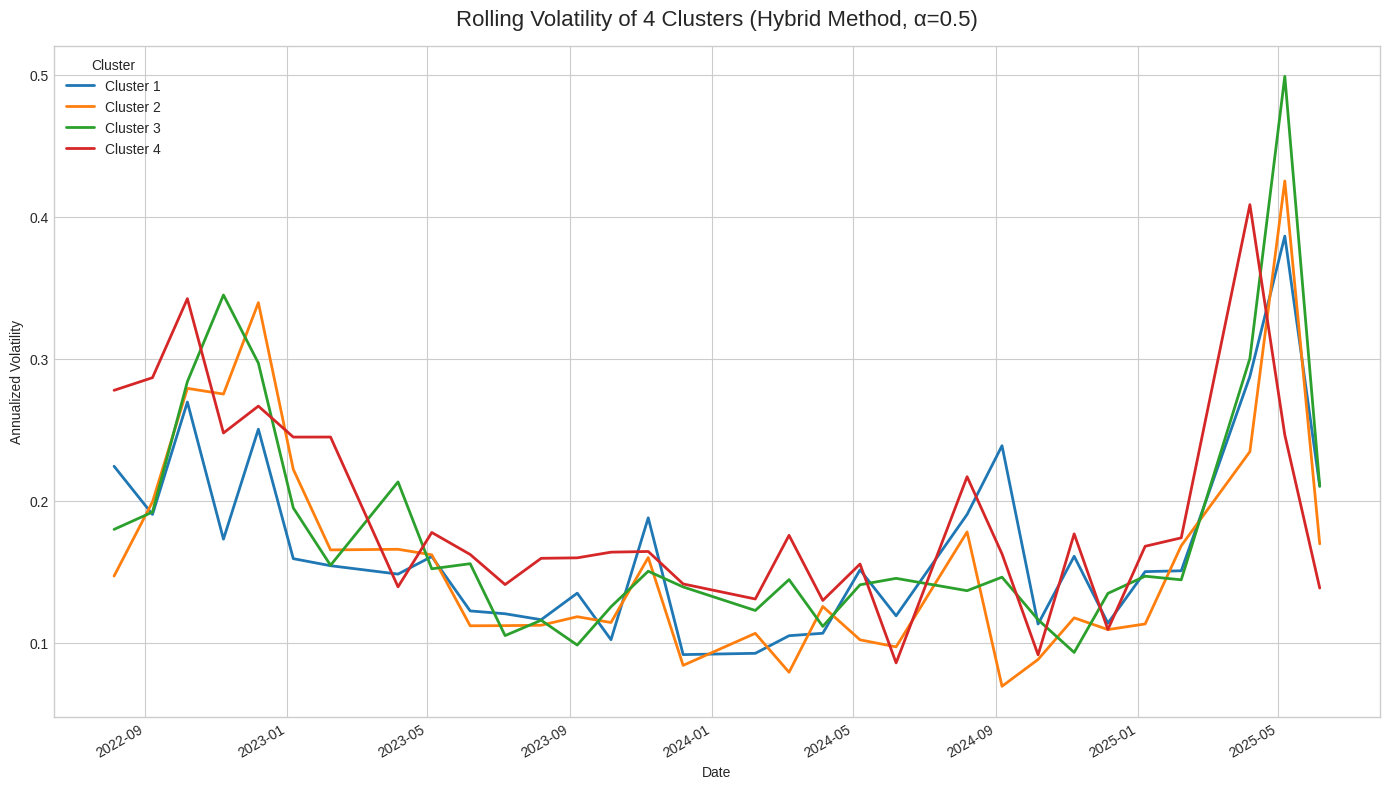


--- Average Performance of Each Cluster (Hybrid Method) ---
           Avg. Return  Avg. Volatility
Cluster 1     0.400479         0.167263
Cluster 2     0.318924         0.159843
Cluster 3     0.448753         0.177344
Cluster 4     0.491259         0.190074

Analysis complete.


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import minmax_scale
import iisignature as isig
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
SP500_TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "BRK-B", "JPM", "V",
    "JNJ", "UNH", "PG", "XOM", "HD", "MA", "LLY", "CVX", "MRK", "BAC",
    "KO", "PFE", "PEP", "ABBV", "COST", "ORCL", "CMCSA", "WMT", "ADBE", "CRM",
    "ACN", "TMO", "NKE", "DIS", "CSCO", "DHR", "INTC", "NFLX", "VZ", "PYPL",
    "QCOM", "AMD", "TXN", "HON", "AMGN", "SBUX", "IBM", "GE", "MDLZ", "LOW"
]
END_DATE = pd.to_datetime('2025-07-07')
START_DATE = END_DATE - pd.DateOffset(years=5)
TRAINING_WINDOW_YEARS = 2
TESTING_WINDOW_MONTHS = 1
SIGNATURE_DEPTH = 2

# --- [Core HRP functions like download_data, build_hrp_portfolio, etc. are included but omitted here for brevity] ---
def download_data(tickers, start, end):
    print(f"Downloading data from {start.strftime('%Y-%m-%d')} to {end.strftime('%Y-%m-%d')}...")
    data = yf.download(tickers, start=start, end=end, progress=False)['Close']
    data = data.dropna(axis=1, how='all')
    initial_columns = data.columns.tolist()
    data = data.dropna()
    final_columns = data.columns.tolist()
    if len(initial_columns) != len(final_columns):
        print(f"Dropped {len(initial_columns) - len(final_columns)} tickers due to missing data.")
    print(f"Downloaded data for {len(final_columns)} tickers.")
    return data

def calculate_distance_matrix_correlation(returns):
    corr_matrix = returns.corr()
    distance_matrix = np.sqrt(0.5 * (1 - corr_matrix))
    return distance_matrix

def calculate_distance_matrix_signature(prices, depth):
    num_assets = prices.shape[1]
    asset_names = prices.columns
    paths = []
    for col in asset_names:
        log_prices = np.log(prices[col].values).reshape(-1, 1)
        time_index = np.linspace(0, 1, len(log_prices)).reshape(-1, 1)
        path = np.hstack([time_index, log_prices])
        paths.append(path)

    kernel_matrix = np.zeros((num_assets, num_assets))
    for i in range(num_assets):
        for j in range(i, num_assets):
            sig_i, sig_j = isig.sig(paths[i], depth), isig.sig(paths[j], depth)
            kernel_matrix[i, j] = np.dot(sig_i, sig_j)
            kernel_matrix[j, i] = kernel_matrix[i, j]

    distance_matrix = np.zeros((num_assets, num_assets))
    for i in range(num_assets):
        for j in range(i + 1, num_assets):
            dist_sq = kernel_matrix[i, i] + kernel_matrix[j, j] - 2 * kernel_matrix[i, j]
            distance_matrix[i, j] = np.sqrt(max(0, dist_sq))
            distance_matrix[j, i] = distance_matrix[i, j]

    return pd.DataFrame(distance_matrix, index=asset_names, columns=asset_names)

def get_quasi_diagonal_order(distance_matrix):
    condensed_distance = squareform(distance_matrix.fillna(0).values)
    linkage_matrix = sch.linkage(condensed_distance, method='single')
    order_indices = sch.dendrogram(linkage_matrix, no_plot=True)['leaves']
    asset_names = distance_matrix.index
    order_names = [asset_names[i] for i in order_indices]
    return order_names, linkage_matrix

def recursive_bisection_weights(covariance_matrix, order):
    weights = pd.Series(1.0, index=covariance_matrix.index)
    clusters = [order]
    while len(clusters) > 0:
        current_cluster = clusters.pop(0)
        if len(current_cluster) == 1: continue

        mid_point = len(current_cluster) // 2
        left_cluster, right_cluster = current_cluster[:mid_point], current_cluster[mid_point:]
        if not left_cluster or not right_cluster: continue

        cov_left, cov_right = covariance_matrix.loc[left_cluster, left_cluster], covariance_matrix.loc[right_cluster, right_cluster]
        var_left, var_right = np.diag(cov_left.values), np.diag(cov_right.values)

        weights_left, weights_right = (1 / var_left) / np.sum(1 / var_left), (1 / var_right) / np.sum(1 / var_right)
        cluster_var_left, cluster_var_right = np.dot(weights_left, np.dot(cov_left, weights_left)), np.dot(weights_right, np.dot(cov_right, weights_right))

        alloc_factor = 1 - cluster_var_left / (cluster_var_left + cluster_var_right) if (cluster_var_left + cluster_var_right) != 0 else 0.5

        weights.loc[left_cluster] *= alloc_factor
        weights.loc[right_cluster] *= (1 - alloc_factor)

        if len(left_cluster) > 1: clusters.append(left_cluster)
        if len(right_cluster) > 1: clusters.append(right_cluster)
    return weights

def build_hrp_portfolio_order(data_train, method='correlation', signature_depth=2, alpha=0.5):
    """Returns just the clustering order for a given method."""
    returns_train = data_train.pct_change().dropna()
    if method == 'correlation':
        distance_matrix = calculate_distance_matrix_correlation(returns_train)
    elif method == 'signature':
        distance_matrix = calculate_distance_matrix_signature(data_train, signature_depth)
    elif method == 'hybrid':
        dist_corr = calculate_distance_matrix_correlation(returns_train)
        dist_sig = calculate_distance_matrix_signature(data_train, signature_depth)
        dist_corr_scaled = pd.DataFrame(minmax_scale(dist_corr.values.flatten()).reshape(dist_corr.shape), index=dist_corr.index, columns=dist_corr.columns)
        dist_sig_scaled = pd.DataFrame(minmax_scale(dist_sig.values.flatten()).reshape(dist_sig.shape), index=dist_sig.index, columns=dist_sig.columns)
        distance_matrix = alpha * dist_sig_scaled + (1 - alpha) * dist_corr_scaled
    else:
        raise ValueError("Method must be 'correlation', 'signature', or 'hybrid'")
    order, _ = get_quasi_diagonal_order(distance_matrix)
    return order

def calculate_portfolio_metrics(portfolio_returns):
    """Slightly simplified metrics calculator for the cluster portfolios."""
    if portfolio_returns.empty: return {'annualized_return': 0, 'annualized_volatility': 0}
    annualized_return = (1 + portfolio_returns).prod()**(252 / len(portfolio_returns)) - 1
    annualized_volatility = portfolio_returns.std() * np.sqrt(252)
    return {'annualized_return': annualized_return, 'annualized_volatility': annualized_volatility}


# --- NEW: Function to get sub-clusters ---
def get_sub_clusters(ordered_assets, num_clusters=4):
    """Splits an ordered list of assets into a specified number of clusters."""
    if num_clusters not in [2, 4]:
        raise ValueError("This function only supports splitting into 2 or 4 clusters.")

    if num_clusters == 2:
        mid_point = len(ordered_assets) // 2
        return [ordered_assets[:mid_point], ordered_assets[mid_point:]]

    if num_clusters == 4:
        # First split
        mid_point_1 = len(ordered_assets) // 2
        primary_cluster_1 = ordered_assets[:mid_point_1]
        primary_cluster_2 = ordered_assets[mid_point_1:]

        # Second splits
        mid_point_c1 = len(primary_cluster_1) // 2
        c1a = primary_cluster_1[:mid_point_c1]
        c1b = primary_cluster_1[mid_point_c1:]

        mid_point_c2 = len(primary_cluster_2) // 2
        c2a = primary_cluster_2[:mid_point_c2]
        c2b = primary_cluster_2[mid_point_c2:]

        return [c1a, c1b, c2a, c2b]


# --- NEW: Cluster Backtesting Function ---
def run_cluster_backtest(data, method, num_clusters=4, alpha=0.5):
    """
    Performs a backtest on the individual clusters themselves.
    """
    print(f"\nRunning backtest on {num_clusters} clusters using the {method.upper()} method...")
    all_dates = data.index.sort_values()
    training_delta = pd.DateOffset(years=TRAINING_WINDOW_YEARS)
    testing_delta = pd.DateOffset(months=TESTING_WINDOW_MONTHS)

    all_results = []

    current_end_train = all_dates[0] + training_delta

    num_iterations = sum(1 for d in pd.date_range(start=current_end_train, end=all_dates[-1] - testing_delta, freq=testing_delta))

    with tqdm(total=num_iterations, desc=f"Cluster Backtest ({method.upper()})") as pbar:
        while current_end_train + testing_delta <= all_dates[-1]:
            training_data = data.loc[current_end_train - training_delta : current_end_train]
            testing_data = data.loc[current_end_train + pd.Timedelta(days=1) : current_end_train + testing_delta]

            if len(training_data) < TRAINING_WINDOW_YEARS * 200 or len(testing_data) < TESTING_WINDOW_MONTHS * 20:
                current_end_train += testing_delta
                continue

            # 1. Determine the clustering order for this window
            order = build_hrp_portfolio_order(training_data, method=method, alpha=alpha)

            # 2. Split into the desired number of sub-clusters
            clusters = get_sub_clusters(order, num_clusters)

            # 3. Calculate performance for each cluster portfolio
            returns_test = testing_data.pct_change().dropna()
            period_results = {'end_date': testing_data.index[-1]}

            for i, cluster in enumerate(clusters):
                if not cluster: continue # Skip if a cluster is empty

                # Create an equal-weighted portfolio for the cluster
                cluster_returns = returns_test[cluster].mean(axis=1)

                # Calculate metrics for this cluster's portfolio
                metrics = calculate_portfolio_metrics(cluster_returns)
                for key, value in metrics.items():
                    period_results[f'C{i+1}_{key}'] = value # e.g., 'C1_annualized_volatility'

            all_results.append(period_results)
            current_end_train += testing_delta
            pbar.update(1)

    return pd.DataFrame(all_results).set_index('end_date')


# --- NEW: Plotting function for cluster risk ---
def plot_cluster_risk_over_time(results_df, title):
    """
    Plots the rolling annualized volatility for each cluster.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(14, 8))

    # Select only the volatility columns to plot
    vol_cols = [col for col in results_df.columns if 'volatility' in col]
    results_df[vol_cols].plot(ax=ax, lw=2)

    ax.set_title(title, fontsize=16, pad=15)
    ax.set_ylabel('Annualized Volatility')
    ax.set_xlabel('Date')
    ax.legend([f"Cluster {i+1}" for i in range(len(vol_cols))], title='Cluster')
    plt.tight_layout()
    plt.show()


# --- Main Execution ---
if __name__ == "__main__":
    print("Starting HRP Analysis...")
    stock_data = download_data(SP500_TICKERS, START_DATE, END_DATE)

    if len(stock_data.columns) < 2:
        print("Not enough valid data for a meaningful backtest. Exiting.")
    else:
        # --- NEW: Run the cluster backtest for the Hybrid method ---
        # This new backtest replaces the previous one for this demonstration

        HYBRID_ALPHA = 0.5
        NUM_CLUSTERS = 4

        cluster_results_df = run_cluster_backtest(
            stock_data,
            method='hybrid',
            num_clusters=NUM_CLUSTERS,
            alpha=HYBRID_ALPHA
        )

        if not cluster_results_df.empty:
            # --- Visualize the results of the cluster backtest ---
            plot_title = f"Rolling Volatility of {NUM_CLUSTERS} Clusters (Hybrid Method, α={HYBRID_ALPHA})"
            plot_cluster_risk_over_time(cluster_results_df, title=plot_title)

            # --- Display final average metrics for each cluster ---
            print("\n--- Average Performance of Each Cluster (Hybrid Method) ---")
            avg_metrics = {}
            for i in range(NUM_CLUSTERS):
                return_col = f'C{i+1}_annualized_return'
                vol_col = f'C{i+1}_annualized_volatility'
                avg_metrics[f'Cluster {i+1}'] = {
                    'Avg. Return': cluster_results_df[return_col].mean(),
                    'Avg. Volatility': cluster_results_df[vol_col].mean()
                }

            summary_df = pd.DataFrame(avg_metrics).T
            print(summary_df.to_string())

        print("\nAnalysis complete.")